In [1]:
# import packages 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# import datasets
orders      = pd.read_csv('orders.csv', nrows=300_000)
products    = pd.read_csv('products.csv')
prior       = pd.read_csv('order_products__prior.csv', nrows=300_000)
aisles      = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')

In [3]:
# dataset shapes
print('Dataset shapes:')
for name, df in [('orders', orders), ('products', products),
                 ('prior', prior), ('aisles', aisles), ('departments', departments)]:
    print(f'  {name:20s}: {df.shape}')

print('\norders sample:')
orders.head(3)

Dataset shapes:
  orders              : (300000, 7)
  products            : (49688, 4)
  prior               : (300000, 4)
  aisles              : (134, 2)
  departments         : (21, 2)

orders sample:


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0


In [4]:
# impute null values
print(' Missing Values BEFORE Cleaning ')
print(orders.isnull().sum())

=== Missing Values BEFORE Cleaning ===
order_id                      0
user_id                       0
eval_set                      0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    18130
dtype: int64


In [5]:
orders['days_since_prior_order'].fillna(
    orders['days_since_prior_order'].mean(), inplace=True
)

In [6]:
print(orders.isnull().sum())

order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


In [7]:
# mapping day no . to day column
dow_map = {0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday',
           4:'Thursday', 5:'Friday', 6:'Saturday'}
orders['order_dow_name'] = orders['order_dow'].map(dow_map)

In [8]:
orders.dtypes

order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
order_dow_name             object
dtype: object

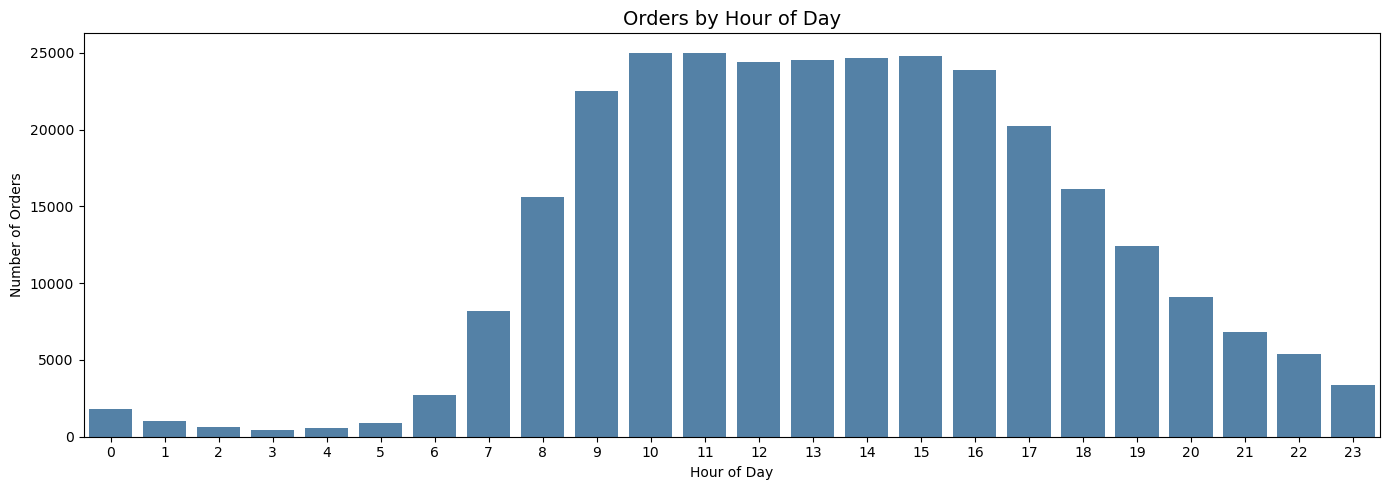

Peak ordering hour: 10:00


In [9]:
# EDA (Exploratory Data Analysis)
# orders by hour of day
plt.figure(figsize=(14, 5))
sns.countplot(x='order_hour_of_day', data=orders, color='steelblue')
plt.title('Orders by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()
# Peak hours
peak = orders['order_hour_of_day'].value_counts().idxmax()
print(f'Peak ordering hour: {peak}:00')

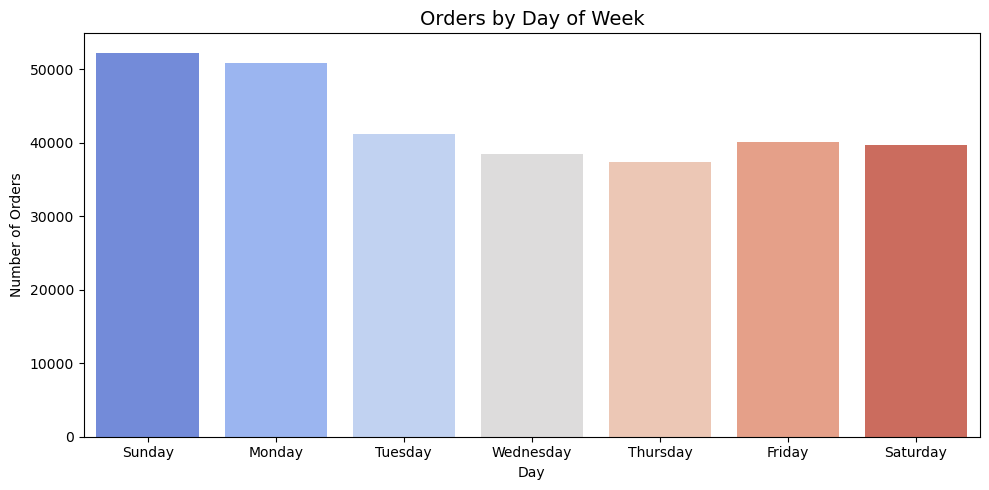

In [10]:
# orders byday of week
day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
plt.figure(figsize=(10, 5))
sns.countplot(x='order_dow_name', data=orders, order=day_order, palette='coolwarm')
plt.title('Orders by Day of Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

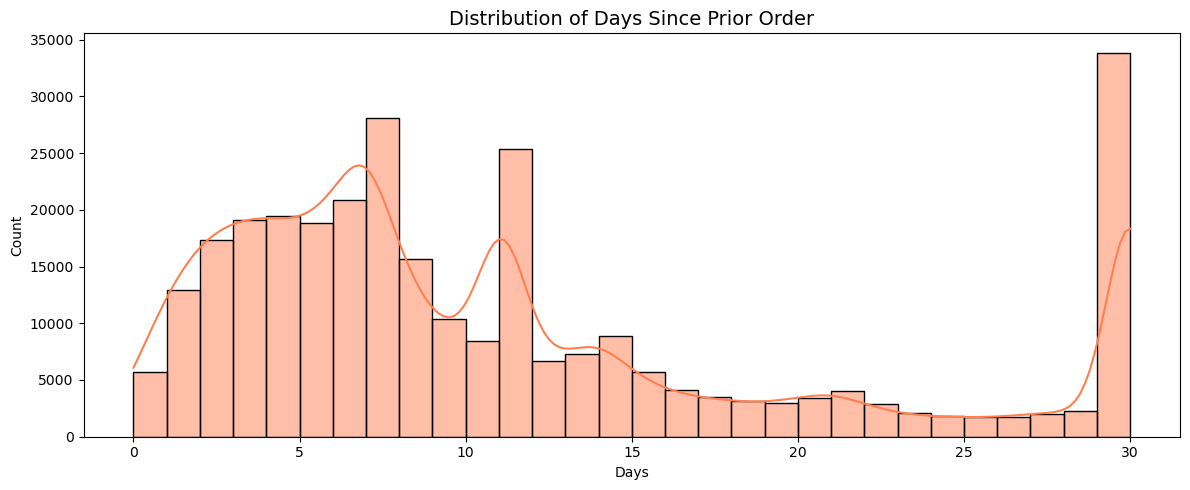

count    300000.00
mean         11.10
std           8.92
min           0.00
25%           5.00
50%           8.00
75%          15.00
max          30.00
Name: days_since_prior_order, dtype: float64


In [11]:
# days since prior order
plt.figure(figsize=(12, 5))
sns.histplot(orders['days_since_prior_order'], bins=30, kde=True, color='coral')
plt.title('Distribution of Days Since Prior Order', fontsize=14)
plt.xlabel('Days')
plt.tight_layout()
plt.show()

print(orders['days_since_prior_order'].describe().round(2))

In [12]:
# merging of tables for rich product information
prior_products = (
    prior
    .merge(products,    on='product_id',   how='left')
    .merge(aisles,      on='aisle_id',     how='left')
    .merge(departments, on='department_id',how='left')
)
print('Merged shape:', prior_products.shape)
prior_products.head(3)

Merged shape: (300000, 9)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry


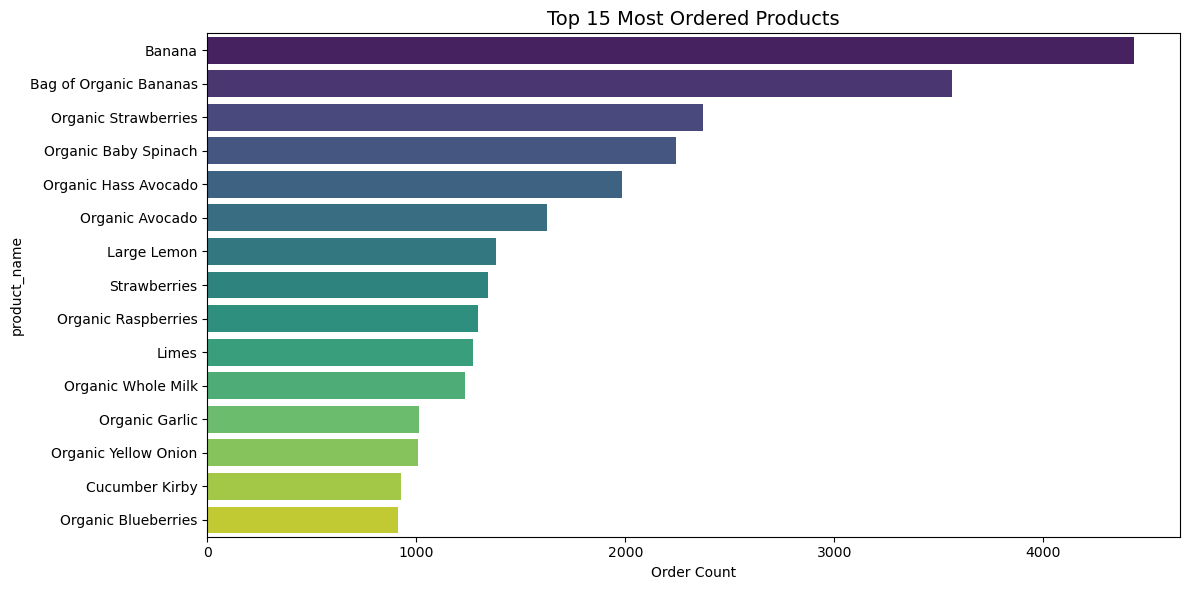

In [13]:
# top 15 products that are ordered
top_products = prior_products['product_name'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 15 Most Ordered Products', fontsize=14)
plt.xlabel('Order Count')
plt.tight_layout()
plt.show()

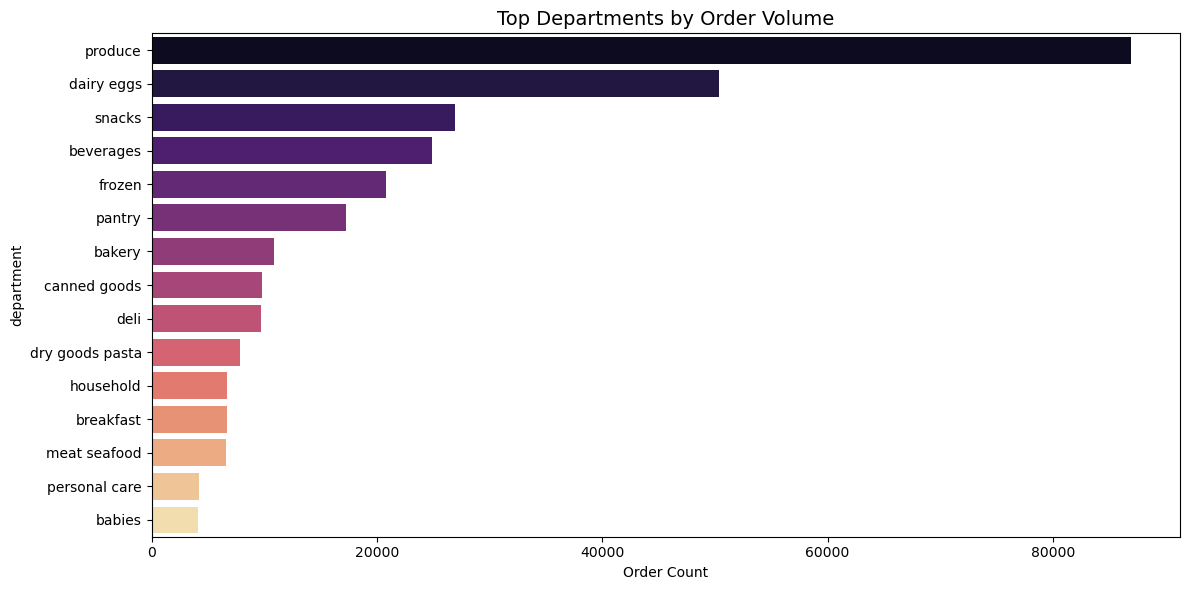

In [14]:
# orders according to department
dept_counts = prior_products['department'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=dept_counts.values, y=dept_counts.index, palette='magma')
plt.title('Top Departments by Order Volume', fontsize=14)
plt.xlabel('Order Count')
plt.tight_layout()
plt.show()

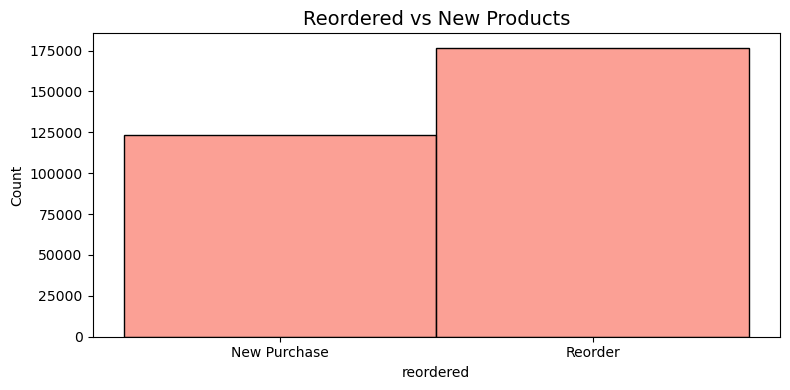

Overall reorder rate: 58.9%


In [15]:
# reorder rate distribution
plt.figure(figsize=(8, 4))
sns.histplot(prior_products['reordered'], discrete=True, color='salmon')
plt.title('Reordered vs New Products', fontsize=14)
plt.xticks([0, 1], ['New Purchase', 'Reorder'])
plt.tight_layout()
plt.show()
reorder_pct = prior_products['reordered'].mean() * 100
print(f'Overall reorder rate: {reorder_pct:.1f}%')

In [16]:
# orders per customer
user_order_counts = (
    orders.groupby('user_id')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'total_orders'})
)

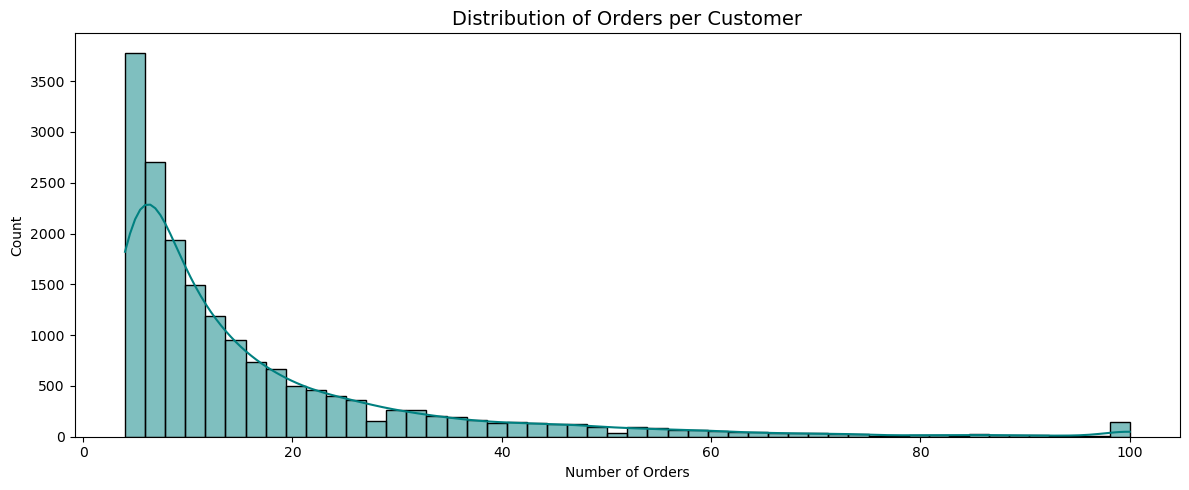

count    18130.00
mean        16.55
std         16.70
min          4.00
25%          6.00
50%         10.00
75%         20.00
max        100.00
Name: total_orders, dtype: float64


In [17]:
plt.figure(figsize=(12, 5))
sns.histplot(user_order_counts['total_orders'], bins=50, kde=True, color='teal')
plt.title('Distribution of Orders per Customer', fontsize=14)
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()
print(user_order_counts['total_orders'].describe().round(2))

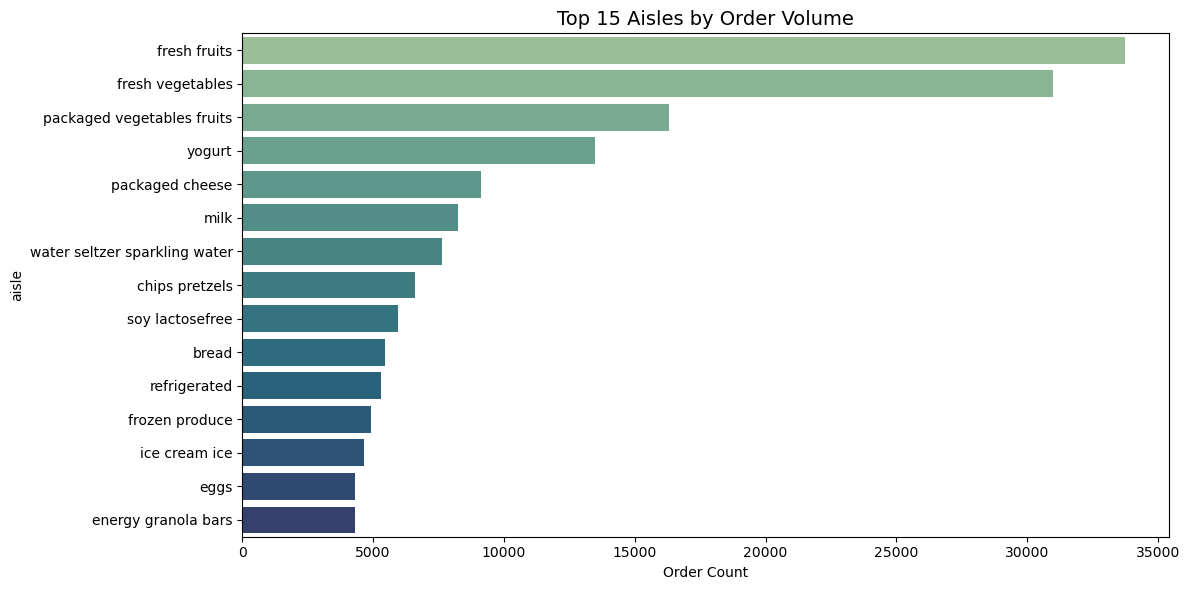

In [18]:
# top aisles
top_aisles = prior_products['aisle'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_aisles.values, y=top_aisles.index, palette='crest')
plt.title('Top 15 Aisles by Order Volume', fontsize=14)
plt.xlabel('Order Count')
plt.tight_layout()
plt.show()

In [19]:
# Feature Engineering for ML
# User-level features 
user_features = orders.groupby('user_id').agg(
    total_orders     = ('order_id',              'count'),
    avg_days_between = ('days_since_prior_order', 'mean'),
    avg_hour         = ('order_hour_of_day',      'mean')
).reset_index()

In [20]:
# Product-level features 
product_features = prior_products.groupby('product_id').agg(
    product_total_orders = ('order_id',          'count'),
    reorder_rate         = ('reordered',          'mean'),
    avg_cart_position    = ('add_to_cart_order',  'mean')
).reset_index()

In [21]:
print('User features shape   :', user_features.shape)
print('Product features shape:', product_features.shape)
user_features.head()

User features shape   : (18130, 4)
Product features shape: (24836, 4)


,user_id,total_orders,avg_days_between,avg_hour
0,1,11,18.281659,10.090909
1,2,15,15.939883,10.600000
2,3,13,11.930635,16.307692
3,4,6,16.016375,12.500000
4,5,5,11.419650,15.000000


In [22]:
# model training
from sklearn.model_selection import train_test_split, cross_val_score

In [23]:
# bulding ml features 
ml_data = prior_products[['product_id', 'add_to_cart_order', 'reordered']].copy()
ml_data = ml_data.merge(
    product_features[['product_id', 'reorder_rate', 'avg_cart_position', 'product_total_orders']],
    on='product_id', how='left'
)

In [24]:
# drop null values
ml_data.dropna(inplace=True)

In [25]:
# set features and target column
FEATURES = ['add_to_cart_order', 'reorder_rate', 'avg_cart_position', 'product_total_orders']
TARGET   = 'reordered'

In [26]:
X = ml_data[FEATURES]
y = ml_data[TARGET]

In [27]:
# training and testing the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
print(f'Train size : {X_train.shape[0]:,}')
print(f'Test  size : {X_test.shape[0]:,}')
print(f'Class balance (y_test):\n{y_test.value_counts(normalize=True).round(3)}')

Train size : 240,000
Test  size : 60,000
Class balance (y_test):
reordered
1    0.589
0    0.411
Name: proportion, dtype: float64


In [29]:
# random forest classifier
from sklearn.ensemble import RandomForestClassifier

In [30]:
# call & assign
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [31]:
# training the data
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [32]:
# importing Scaler , Encoders and metrices
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score, accuracy_score,  confusion_matrix, ConfusionMatrixDisplay)

In [33]:
# predictiond on random forest model
y_pred_rf   = rf_model.predict(X_test)
y_proba_rf  = rf_model.predict_proba(X_test)[:, 1]

In [34]:
# accuracy score
rf_acc      = accuracy_score(y_test, y_pred_rf)
rf_auc      = roc_auc_score(y_test, y_proba_rf)
print(f'\n  Random Forest — Accuracy: {rf_acc:.4f}  |  ROC-AUC: {rf_auc:.4f}')


  Random Forest — Accuracy: 0.6375  |  ROC-AUC: 0.6572


In [35]:
# classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.57      0.46      0.51     24659
           1       0.67      0.76      0.71     35341

    accuracy                           0.64     60000
   macro avg       0.62      0.61      0.61     60000
weighted avg       0.63      0.64      0.63     60000



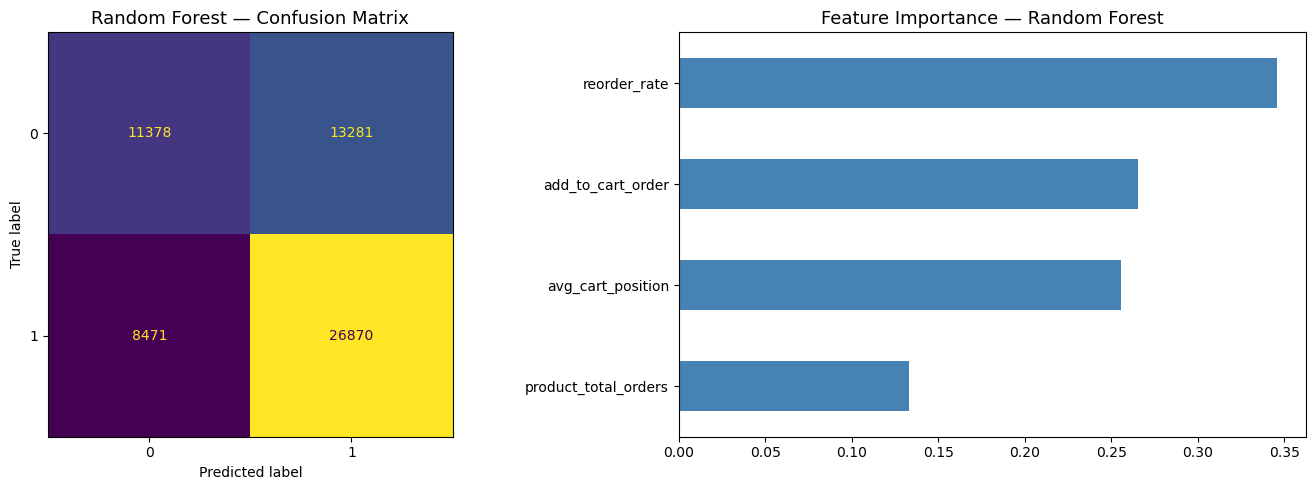

In [36]:
#  Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest — Confusion Matrix', fontsize=13)

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance — Random Forest', fontsize=13)

plt.tight_layout()
plt.show()

In [37]:
# model saving
import joblib
import os

In [38]:
# Save model
joblib.dump(rf_model, 'models/random_forest.pkl1')
print('Random Forest model saved → models/random_forest.pkl')

Random Forest model saved → models/random_forest.pkl


In [39]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

In [40]:
# scale the features 
scaler_lr = StandardScaler()

In [41]:
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled  = scaler_lr.transform(X_test)

In [42]:
# call & assign 
lr_model = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)

In [43]:
# model training
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=500, n_jobs=-1, random_state=42)

In [44]:
# predictions
y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [45]:
# accuracy
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_proba_lr)
print(f'\n  Logistic Regression — Accuracy: {lr_acc:.4f}  |  ROC-AUC: {lr_auc:.4f}')


  Logistic Regression — Accuracy: 0.6845  |  ROC-AUC: 0.7306


In [46]:
# classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.67      0.46      0.54     24659
           1       0.69      0.84      0.76     35341

    accuracy                           0.68     60000
   macro avg       0.68      0.65      0.65     60000
weighted avg       0.68      0.68      0.67     60000



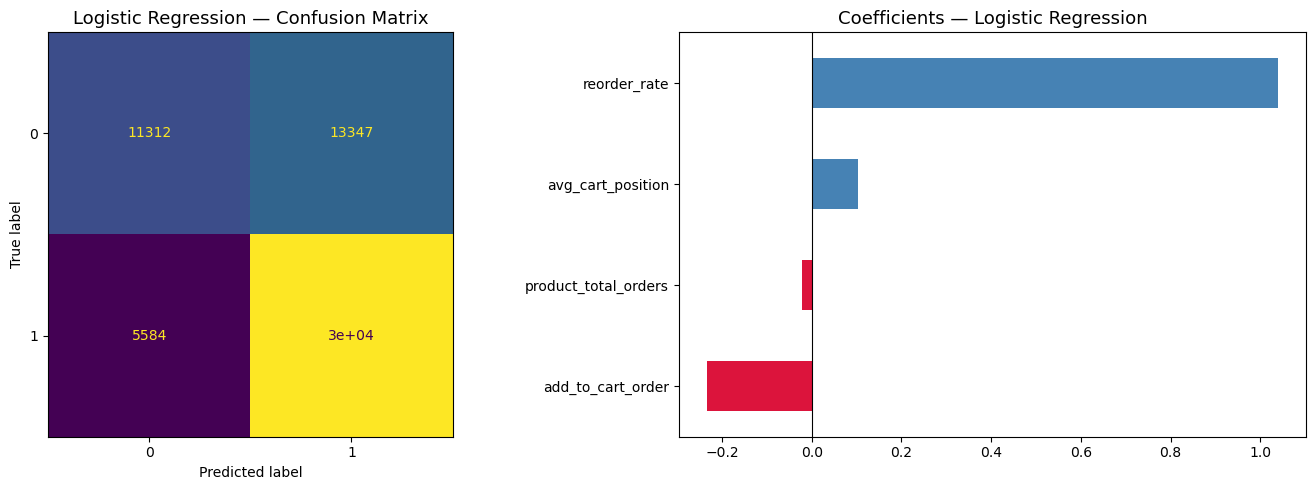

In [47]:
# Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression — Confusion Matrix', fontsize=13)

# Coefficients (importance for LR)
coef = pd.Series(lr_model.coef_[0], index=FEATURES).sort_values()
coef.plot(kind='barh', ax=axes[1], color=['crimson' if v < 0 else 'steelblue' for v in coef])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Coefficients — Logistic Regression', fontsize=13)

plt.tight_layout()
plt.show()

In [48]:
# Save model + scaler together
joblib.dump(lr_model,   'models/logistic_regression1.pkl')
joblib.dump(scaler_lr,  'models/scaler_lr1.pkl')

['models/scaler_lr1.pkl']

In [49]:
# XGBoost Classifier
from xgboost import XGBClassifier

In [50]:
# xgb define parameters and assign values
xgb_model = XGBClassifier(
    n_estimators    = 200,
    max_depth       = 5,
    learning_rate   = 0.1,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    use_label_encoder = False,
    eval_metric     = 'logloss',
    random_state    = 42,
    n_jobs          = -1
)

In [51]:
# train the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [52]:
# predictions on model
y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [53]:
# accuracy
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)
print(f'\n  XGBoost — Accuracy: {xgb_acc:.4f}  |  ROC-AUC: {xgb_auc:.4f}')


  XGBoost — Accuracy: 0.6836  |  ROC-AUC: 0.7294


In [54]:
# classification report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.68      0.44      0.53     24659
           1       0.69      0.85      0.76     35341

    accuracy                           0.68     60000
   macro avg       0.68      0.65      0.65     60000
weighted avg       0.68      0.68      0.67     60000



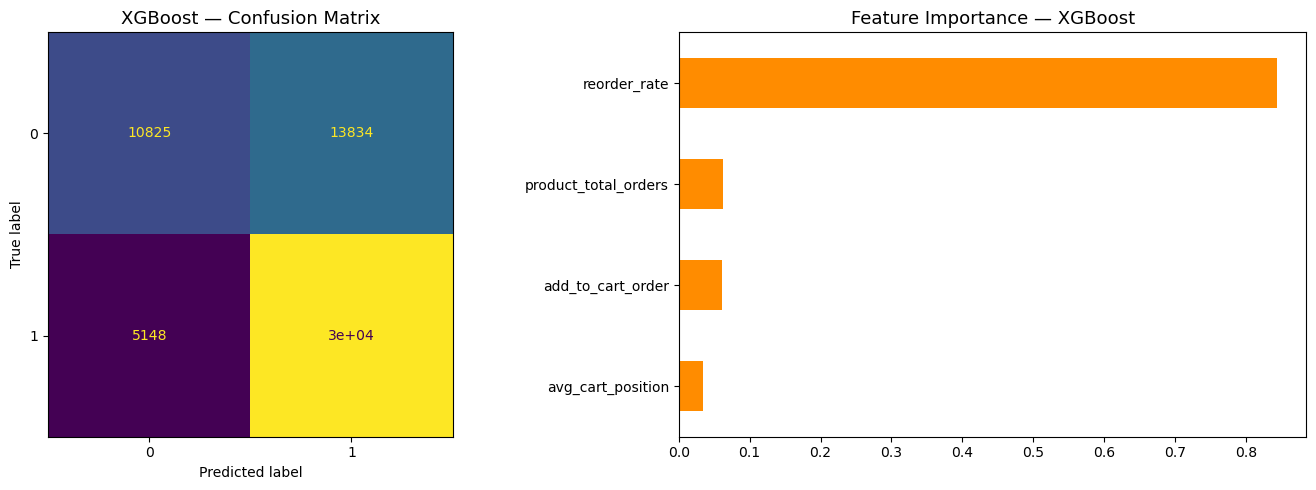

In [55]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[0], colorbar=False)
axes[0].set_title('XGBoost — Confusion Matrix', fontsize=13)

# Feature importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance — XGBoost', fontsize=13)

plt.tight_layout()
plt.show()

In [56]:
# Save model
joblib.dump(xgb_model, 'models/xgboost.pkl1')
print(' XGBoost model saved → models/xgboost.pkl')

 XGBoost model saved → models/xgboost.pkl


In [57]:
# K - Means Clustering
from sklearn.cluster import KMeans

In [58]:
# prepare segements for k-means
seg_data = user_features[['total_orders', 'avg_days_between', 'avg_hour']].dropna().copy()

In [59]:
# scaling the data 
scaler_km = StandardScaler()
seg_scaled = scaler_km.fit_transform(seg_data)

In [60]:
# ellbow method
inertias = []
K_range  = range(2, 10)
for k in K_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(seg_scaled)
    inertias.append(km_temp.inertia_)

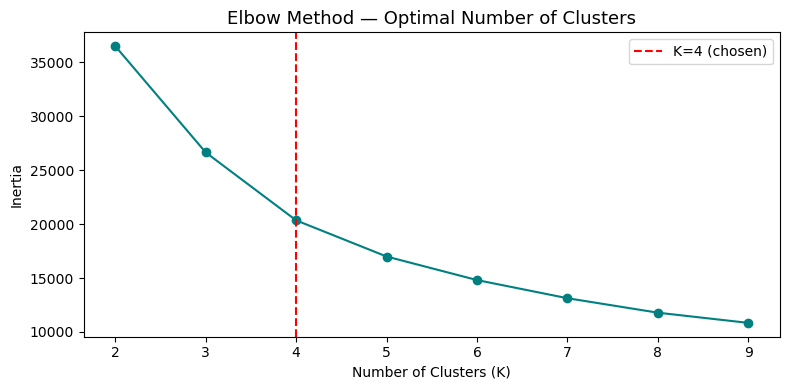

In [61]:
# plotting the points
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='teal')
plt.axvline(4, color='red', linestyle='--', label='K=4 (chosen)')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# fit k-means 
K = 4
km_model = KMeans(n_clusters=K, random_state=42, n_init=10)
seg_data['cluster'] = km_model.fit_predict(seg_scaled)

In [63]:
print('=== Cluster Summary (mean values) ===')
summary = seg_data.groupby('cluster').mean().round(2)
summary['size'] = seg_data.groupby('cluster').size()
print(summary)

=== Cluster Summary (mean values) ===
         total_orders  avg_days_between  avg_hour  size
cluster                                                
0               17.11             10.50     13.09  6283
1                9.38             17.57     15.72  5152
2               57.44              6.36     13.31  1818
3                8.15             19.94     12.06  4877


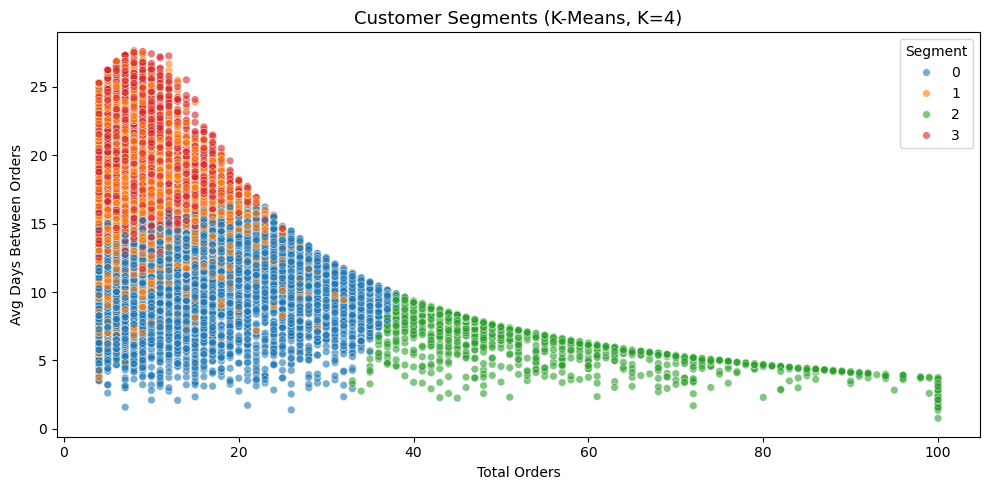

In [64]:
# scatter plots
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=seg_data, x='total_orders', y='avg_days_between',
    hue='cluster', palette='tab10', alpha=0.6, s=30
)
plt.title('Customer Segments (K-Means, K=4)', fontsize=13)
plt.xlabel('Total Orders')
plt.ylabel('Avg Days Between Orders')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

In [65]:
# Save model + scaler
joblib.dump(km_model,  'models/kmeans.pkl1')
joblib.dump(scaler_km, 'models/scaler_km.pkl1')

['models/scaler_km.pkl1']

# Market Basket Analysis

In [66]:
# use fpgrowth , association rules
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [67]:
# use a sample of 5,000 orders for speed
sample_ids = prior_products['order_id'].drop_duplicates().sample(5000, random_state=42)
sample_orders = prior_products[prior_products['order_id'].isin(sample_ids)]

In [68]:
# Pivot: rows = orders, columns = products, values = 0/1
basket = (
    sample_orders
    .groupby(['order_id', 'product_name'])['reordered']
    .max()
    .unstack()
    .fillna(0)
    .astype(int)
)
print(f'Basket matrix shape: {basket.shape}  (orders × products)')

Basket matrix shape: (5000, 11692)  (orders × products)


In [69]:
# fpgrowth
frequent_items = fpgrowth(basket, min_support=0.02, use_colnames=True)

C:\Users\RD\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [70]:
# association rules
rules = association_rules(frequent_items, metric='lift', min_threshold=1.2)

In [71]:
# sorting 
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

In [72]:
print(f'Frequent itemsets : {len(frequent_items)}')
print(f'Association rules : {len(rules)}')
print('\nTop 10 Rules by Lift:')
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
rules[display_cols].head(10)

Frequent itemsets : 21
Association rules : 0

Top 10 Rules by Lift:


,antecedents,consequents,support,confidence,lift


In [73]:
# accuracy & ROC - AUC comparison table
comparison = pd.DataFrame({
    'Model'    : ['Random Forest', 'Logistic Regression', 'XGBoost'],
    'Accuracy' : [rf_acc,          lr_acc,                xgb_acc],
    'ROC-AUC'  : [rf_auc,          lr_auc,                xgb_auc],
})
comparison = comparison.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
comparison = comparison.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
comparison['Accuracy'] = comparison['Accuracy'].map('{:.4f}'.format)
comparison['ROC-AUC']  = comparison['ROC-AUC'].map('{:.4f}'.format)
print('=== Model Comparison ===')
comparison

=== Model Comparison ===


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.6845,0.7306
1,XGBoost,0.6836,0.7294
2,Random Forest,0.6375,0.6572


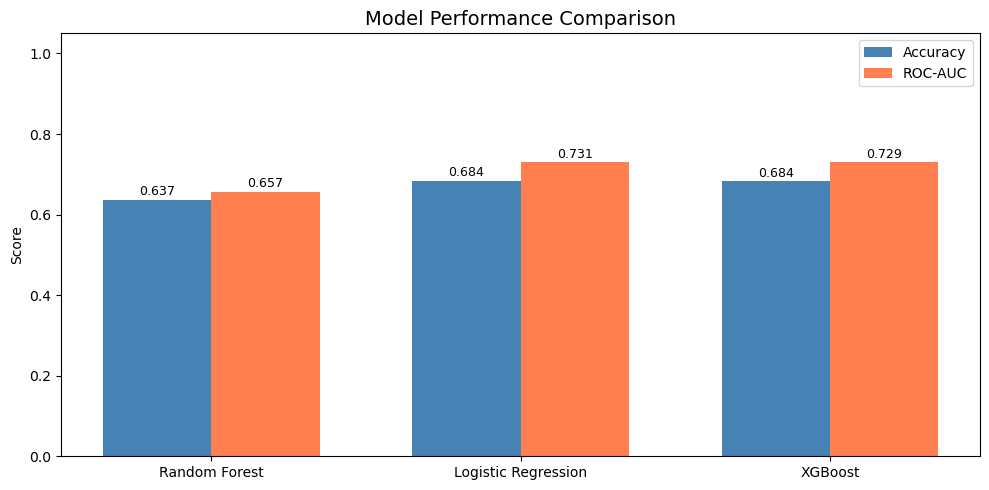

In [74]:
# bar chart comparison
models    = ['Random Forest', 'Logistic Regression', 'XGBoost']
acc_vals  = [rf_acc, lr_acc, xgb_acc]
auc_vals  = [rf_auc, lr_auc, xgb_auc]
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, auc_vals, width, label='ROC-AUC',  color='coral')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Annotate bars
for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [75]:
# Verify all saved models 
print('=== Saved Models ===')
for fname in os.listdir('models'):
    fpath = os.path.join('models', fname)
    fsize = os.path.getsize(fpath) / 1024
    print(f'  {fname:35s} ({fsize:.1f} KB)')

=== Saved Models ===
  kmeans.pkl                          (71.6 KB)
  kmeans.pkl1                         (71.6 KB)
  logistic_regression.pkl             (0.9 KB)
  logistic_regression1.pkl            (0.9 KB)
  random_forest.pkl                   (649232.1 KB)
  random_forest.pkl1                  (649232.1 KB)
  scaler_km.pkl                       (1.0 KB)
  scaler_km.pkl1                      (1.0 KB)
  scaler_lr.pkl                       (1.1 KB)
  scaler_lr1.pkl                      (1.1 KB)
  xgboost.pkl                         (444.8 KB)
  xgboost.pkl1                        (444.8 KB)
